# Predicting E-Commerce Purchase Likelihood Using an Optimized Classification Model

**Project objective:** Build and optimize a binary classification model that predicts whether an
e-commerce visitor will complete a purchase, based on browsing behavior, transaction history,
engagement level, and demographic information. The final model should provide a purchase
prediction, a purchase-probability score, an explanation of the most influential features, and
business recommendations for the marketing team.

**Business question:** Based on customer behavior and profile information, can we predict whether
a customer is likely to make a purchase — and which behaviors matter most?


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100


## 1. Dataset Description

No pre-existing dataset was supplied for this project, so a structured synthetic e-commerce
dataset is generated below. Feature distributions and the relationship between behavior and
purchase are designed to mimic realistic e-commerce dynamics (e.g. more cart items, more prior
purchases, and higher engagement raise purchase probability; a long gap since the last visit
lowers it), so the modeling workflow below reflects patterns a real dataset would also contain.


In [2]:
n_customers = 6000

customer_id = np.arange(1, n_customers + 1)
age = np.random.normal(35, 11, n_customers).clip(16, 75).round().astype(int)
gender = np.random.choice(["Female", "Male", "Other"], n_customers, p=[0.48, 0.48, 0.04])
location = np.random.choice(
    ["North", "South", "East", "West", "Central"], n_customers, p=[0.22, 0.2, 0.2, 0.2, 0.18]
)
device_type = np.random.choice(["Mobile", "Desktop", "Tablet"], n_customers, p=[0.55, 0.35, 0.10])
traffic_source = np.random.choice(
    ["Search", "Social", "Email", "Direct", "Ad"], n_customers, p=[0.3, 0.25, 0.15, 0.15, 0.15]
)

pages_viewed = np.random.poisson(8, n_customers) + 1
time_on_site = (np.random.gamma(2.0, 90, n_customers)).round(1)          # seconds
products_viewed = np.random.poisson(5, n_customers)
cart_items = np.random.poisson(1.2, n_customers)
previous_purchases = np.random.poisson(1.5, n_customers)
average_order_value = (np.random.gamma(2.5, 20, n_customers)).round(2)
discount_used = np.random.choice([0, 1], n_customers, p=[0.65, 0.35])
email_clicked = np.random.choice([0, 1], n_customers, p=[0.7, 0.3])
ad_clicked = np.random.choice([0, 1], n_customers, p=[0.75, 0.25])
review_score_viewed = np.random.normal(3.9, 0.6, n_customers).clip(1, 5).round(2)
days_since_last_visit = np.random.exponential(15, n_customers).round().astype(int)
session_count = np.random.poisson(3, n_customers) + 1

# Latent purchase propensity: a weighted, noisy combination of the behavioral signals
z = (
    -3.2
    + 0.28 * cart_items
    + 0.22 * previous_purchases
    + 0.015 * time_on_site
    + 0.05 * products_viewed
    + 0.05 * pages_viewed
    + 0.55 * discount_used
    + 0.35 * email_clicked
    + 0.20 * ad_clicked
    + 0.30 * (review_score_viewed - 3.9)
    + 0.10 * session_count
    - 0.03 * days_since_last_visit
    + 0.15 * (device_type == "Desktop")
    - 0.10 * (traffic_source == "Ad")
    + np.random.normal(0, 0.75, n_customers)
)
purchase_prob_true = 1 / (1 + np.exp(-z))
purchase = np.random.binomial(1, purchase_prob_true)

df = pd.DataFrame({
    "CustomerID": customer_id,
    "Age": age,
    "Gender": gender,
    "Location": location,
    "DeviceType": device_type,
    "TrafficSource": traffic_source,
    "PagesViewed": pages_viewed,
    "TimeOnSite": time_on_site,
    "ProductsViewed": products_viewed,
    "CartItems": cart_items,
    "PreviousPurchases": previous_purchases,
    "AverageOrderValue": average_order_value,
    "DiscountUsed": discount_used,
    "EmailClicked": email_clicked,
    "AdClicked": ad_clicked,
    "ReviewScoreViewed": review_score_viewed,
    "DaysSinceLastVisit": days_since_last_visit,
    "SessionCount": session_count,
    "Purchase": purchase,
})

# Inject a small amount of realistic messiness: missing values and a few duplicate rows
missing_mask = np.random.rand(n_customers) < 0.03
df.loc[missing_mask, "AverageOrderValue"] = np.nan
missing_mask2 = np.random.rand(n_customers) < 0.02
df.loc[missing_mask2, "ReviewScoreViewed"] = np.nan
df = pd.concat([df, df.sample(25, random_state=RANDOM_STATE)], ignore_index=True)

df.to_csv("../data/ecommerce_customer_data.csv", index=False)
df.head()


,CustomerID,Age,Gender,Location,DeviceType,TrafficSource,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,Purchase
0,1,40,Female,South,Desktop,Direct,6,240.7,4,1,1,86.58,1,1,0,3.41,8,4,1
1,2,33,Female,East,Desktop,Direct,5,520.0,3,2,4,48.12,0,0,0,3.64,7,2,1
2,3,42,Female,East,Mobile,Search,11,123.5,3,4,4,53.87,0,1,0,3.79,8,4,1
3,4,52,Female,Central,Mobile,Social,3,128.2,6,0,0,47.39,0,0,1,4.14,15,6,1
4,5,32,Male,South,Mobile,Social,12,153.6,4,0,3,79.36,0,1,0,4.22,3,3,0


## 2. Data-Quality Checks

Row/column counts, dtypes, target distribution, missing values, duplicates, and basic descriptive
statistics.

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (6025, 19)
<class 'pandas.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          6025 non-null   int64  
 1   Age                 6025 non-null   int64  
 2   Gender              6025 non-null   str    
 3   Location            6025 non-null   str    
 4   DeviceType          6025 non-null   str    
 5   TrafficSource       6025 non-null   str    
 6   PagesViewed         6025 non-null   int64  
 7   TimeOnSite          6025 non-null   float64
 8   ProductsViewed      6025 non-null   int64  
 9   CartItems           6025 non-null   int64  
 10  PreviousPurchases   6025 non-null   int64  
 11  AverageOrderValue   5840 non-null   float64
 12  DiscountUsed        6025 non-null   int64  
 13  EmailClicked        6025 non-null   int64  
 14  AdClicked           6025 non-null   int64  
 15  ReviewScoreViewed   5904 non-null   float64
 16 

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicate rows: 25

Missing values per column:
AverageOrderValue    185
ReviewScoreViewed    121
dtype: int64


In [5]:
purchase_rate = df["Purchase"].mean()
print(f"Purchase rate: {purchase_rate:.2%}")
print(f"Non-purchase rate: {1 - purchase_rate:.2%}")
df["Purchase"].value_counts(normalize=True)


Purchase rate: 65.59%
Non-purchase rate: 34.41%


Purchase
1    0.655934
0    0.344066
Name: proportion, dtype: float64

In [6]:
df.describe()


,CustomerID,Age,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,Purchase
count,6025.000000,6025.00000,6025.000000,6025.000000,6025.000000,6025.000000,6025.00000,5840.000000,6025.000000,6025.000000,6025.000000,5904.000000,6025.000000,6025.000000,6025.000000
mean,2997.785560,35.17527,9.009461,179.974656,4.965975,1.238672,1.50556,50.278106,0.357344,0.305560,0.252116,3.898784,14.726971,4.029544,0.655934
std,1733.186844,10.59010,2.805931,127.641353,2.229601,1.107501,1.23541,32.393481,0.479257,0.460683,0.434264,0.573524,14.669748,1.717554,0.475102
min,1.000000,16.00000,1.000000,3.000000,0.000000,0.000000,0.00000,0.240000,0.000000,0.000000,0.000000,1.780000,0.000000,1.000000,0.000000
25%,1497.000000,28.00000,7.000000,85.100000,3.000000,0.000000,1.00000,25.990000,0.000000,0.000000,0.000000,3.510000,4.000000,3.000000,0.000000
50%,2996.000000,35.00000,9.000000,151.700000,5.000000,1.000000,1.00000,43.350000,0.000000,0.000000,0.000000,3.900000,10.000000,4.000000,1.000000
75%,4499.000000,42.00000,11.000000,244.100000,6.000000,2.000000,2.00000,67.250000,1.000000,1.000000,1.000000,4.290000,21.000000,5.000000,1.000000
max,6000.000000,75.00000,21.000000,1220.100000,20.000000,6.000000,8.00000,296.040000,1.000000,1.000000,1.000000,5.000000,159.000000,12.000000,1.000000


**Observations:**
- `CustomerID` is a unique identifier and carries no predictive signal — it will be dropped before
  modeling.
- A small fraction of `AverageOrderValue` and `ReviewScoreViewed` values are missing; these will be
  median-imputed inside the preprocessing pipeline.
- A handful of duplicate rows were introduced and will be removed.
- The target is moderately imbalanced (purchasers are the minority class), so accuracy alone will
  not be a reliable evaluation metric and stratified splitting/cross-validation will be used.


## 3. Exploratory Data Analysis


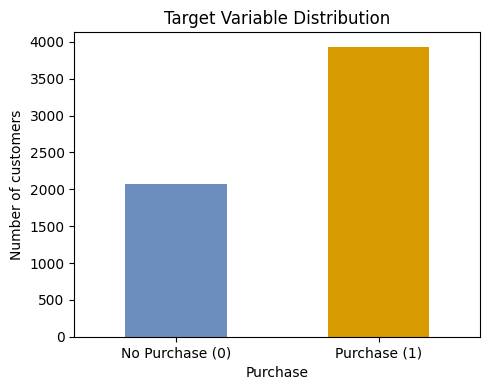

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5, 4))
df["Purchase"].value_counts().sort_index().plot(kind="bar", color=["#6c8ebf", "#d79b00"], ax=ax)
ax.set_xticklabels(["No Purchase (0)", "Purchase (1)"], rotation=0)
ax.set_ylabel("Number of customers")
ax.set_title("Target Variable Distribution")
plt.tight_layout()
plt.show()


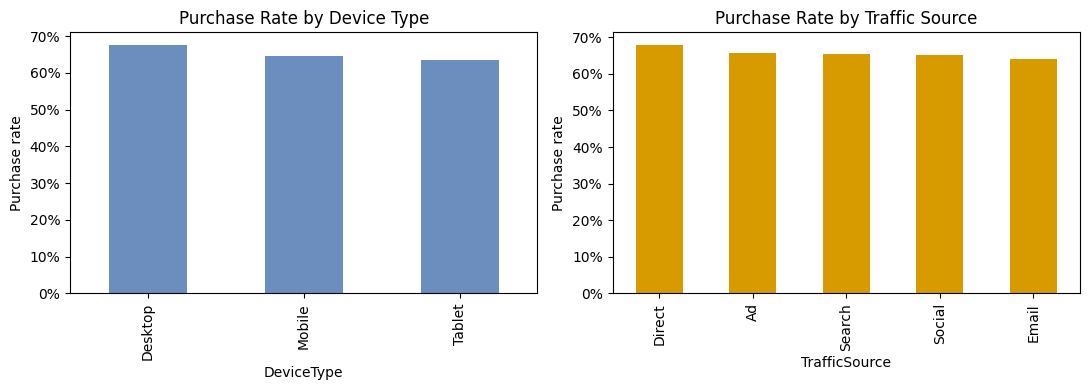

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

device_rate = df.groupby("DeviceType")["Purchase"].mean().sort_values(ascending=False)
device_rate.plot(kind="bar", ax=axes[0], color="#6c8ebf")
axes[0].set_title("Purchase Rate by Device Type")
axes[0].set_ylabel("Purchase rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

traffic_rate = df.groupby("TrafficSource")["Purchase"].mean().sort_values(ascending=False)
traffic_rate.plot(kind="bar", ax=axes[1], color="#d79b00")
axes[1].set_title("Purchase Rate by Traffic Source")
axes[1].set_ylabel("Purchase rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


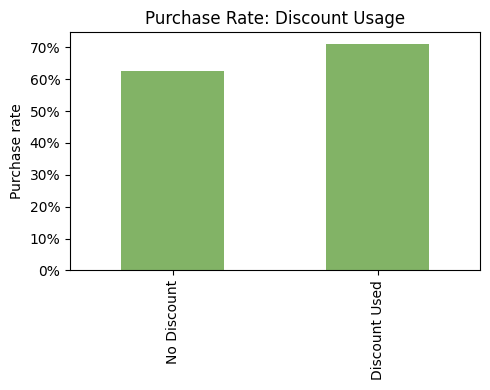

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
discount_rate = df.groupby("DiscountUsed")["Purchase"].mean()
discount_rate.index = ["No Discount", "Discount Used"]
discount_rate.plot(kind="bar", color="#82b366", ax=ax)
ax.set_ylabel("Purchase rate")
ax.set_title("Purchase Rate: Discount Usage")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


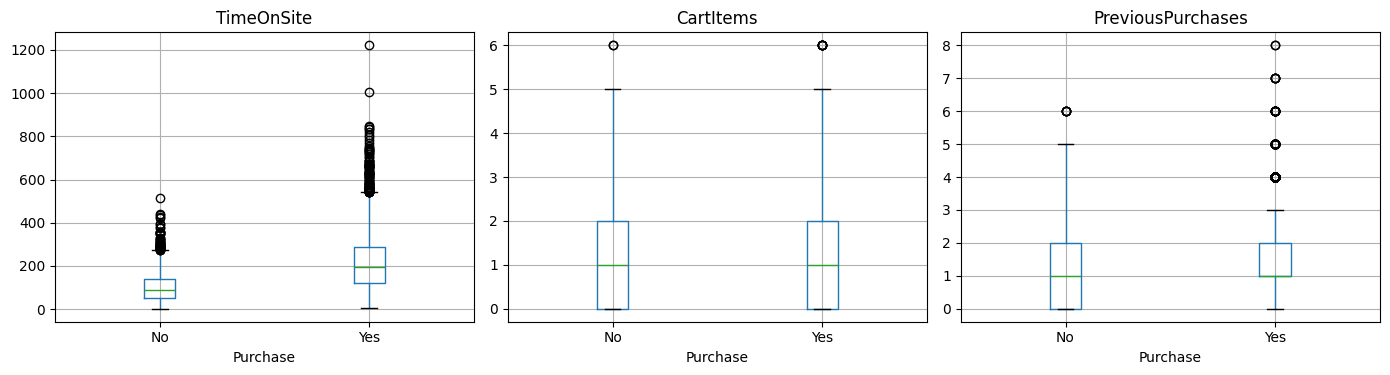

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["TimeOnSite", "CartItems", "PreviousPurchases"]):
    df.boxplot(column=col, by="Purchase", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Purchase")
    ax.set_xticklabels(["No", "Yes"])

plt.suptitle("")
plt.tight_layout()
plt.show()


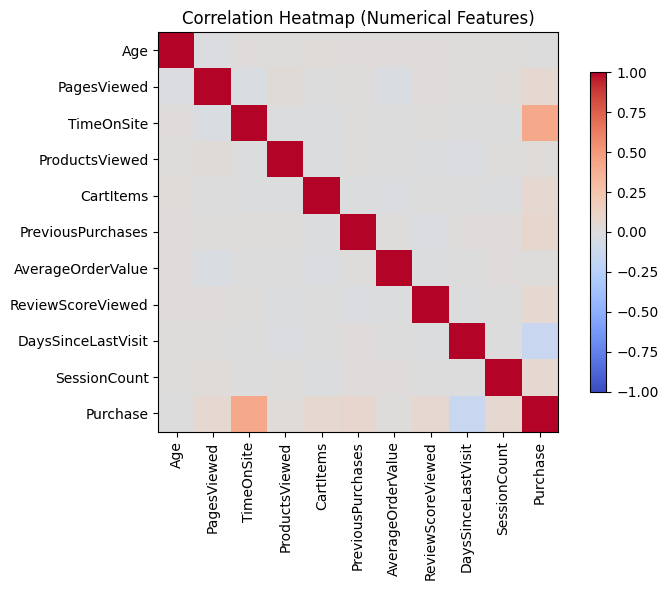

Purchase              1.000000
TimeOnSite            0.421603
PreviousPurchases     0.079492
CartItems             0.066493
PagesViewed           0.062992
SessionCount          0.058294
ReviewScoreViewed     0.058211
ProductsViewed        0.016724
AverageOrderValue     0.002554
Age                  -0.001631
DaysSinceLastVisit   -0.145072
Name: Purchase, dtype: float64

In [11]:
numeric_cols = [
    "Age", "PagesViewed", "TimeOnSite", "ProductsViewed", "CartItems",
    "PreviousPurchases", "AverageOrderValue", "ReviewScoreViewed",
    "DaysSinceLastVisit", "SessionCount", "Purchase"
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

corr["Purchase"].sort_values(ascending=False)


**Business interpretation of the EDA:**
- The target is imbalanced toward non-purchasers, confirming the need for stratified
  splitting and metrics beyond accuracy.
- Desktop and Search/Direct traffic show somewhat higher conversion than Mobile/Ad traffic —
  useful for channel-level budget allocation.
- Customers who received/used a discount convert at a visibly higher rate, suggesting
  price sensitivity plays a role in the purchase decision.
- Purchasers tend to have more items in their cart, spend more time on the site, and have more
  prior purchases than non-purchasers — these look like the strongest behavioral signals and are
  confirmed as the top correlates of `Purchase` in the heatmap.


## 4. Data Preparation

Remove the identifier column, separate features/target, and split into train/test sets with
stratification so both sets preserve the purchase/non-purchase ratio.

In [12]:
model_df = df.drop(columns=["CustomerID"])

X = model_df.drop(columns=["Purchase"])
y = model_df["Purchase"]

categorical_columns = ["Gender", "Location", "DeviceType", "TrafficSource"]
numerical_columns = [c for c in X.columns if c not in categorical_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train purchase rate:", y_train.mean().round(3), " Test purchase rate:", y_test.mean().round(3))


Train shape: (4800, 17)  Test shape: (1200, 17)
Train purchase rate: 0.655  Test purchase rate: 0.656


## 5. Preprocessing Pipeline

A `ColumnTransformer` handles numerical (median imputation + scaling) and categorical
(most-frequent imputation + one-hot encoding) columns separately, and is fit **only** on the
training data inside each model pipeline — preventing data leakage from the test set.

In [13]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])


## 6. Baseline Model Training

Three algorithms are trained with default/basic parameters: Logistic Regression (interpretable
linear baseline), Decision Tree (captures nonlinear rules), and Random Forest (ensemble,
typically stronger generalization).

In [14]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])

baseline_models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline,
}

for name, pipe in baseline_models.items():
    pipe.fit(X_train, y_train)
print("Baseline models trained.")


Baseline models trained.


## 7. Baseline Model Evaluation

Each model is evaluated with accuracy, precision, recall, F1-score, and ROC-AUC on the held-out
test set.

In [15]:
def evaluate_model(name, pipe, X_test, y_test):
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    }

baseline_results = [evaluate_model(name, pipe, X_test, y_test) for name, pipe in baseline_models.items()]
baseline_results_df = pd.DataFrame(baseline_results).set_index("Model").round(3)
baseline_results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.759,0.792,0.858,0.824,0.827
Decision Tree,0.664,0.752,0.728,0.740,0.635
Random Forest,0.748,0.784,0.850,0.816,0.805


In [16]:
best_baseline_name = baseline_results_df["F1-Score"].idxmax()
print("Best baseline model by F1-score:", best_baseline_name)
print()
print(classification_report(y_test, baseline_models[best_baseline_name].predict(X_test)))


Best baseline model by F1-score: Logistic Regression

              precision    recall  f1-score   support

           0       0.68      0.57      0.62       413
           1       0.79      0.86      0.82       787

    accuracy                           0.76      1200
   macro avg       0.74      0.71      0.72      1200
weighted avg       0.75      0.76      0.75      1200



## 8. Selecting the Optimization Metric

The business wants to prioritize customers likely to buy without wasting marketing spend on
unlikely buyers, but also does not want to miss too many genuine buyers — this is a **balance**
of precision and recall, so **F1-score** is used as the primary optimization metric for
hyperparameter search, with ROC-AUC and recall reported alongside it since ranking customers by
purchase probability (for remarketing prioritization) also matters to the business.

## 9. Hyperparameter Optimization

Random Forest and Logistic Regression are tuned with `GridSearchCV` (5-fold stratified
cross-validation, optimizing F1-score). A modest grid is used to keep runtime reasonable while
still covering the parameters most likely to matter.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 8, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"],
}

rf_search = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=rf_param_grid,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_search.best_params_)
print("Best CV F1-score:", round(rf_search.best_score_, 4))


Best Random Forest parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 8, 'classifier__class_weight': None}
Best CV F1-score: 0.8144


In [18]:
logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
    "classifier__class_weight": [None, "balanced"],
}

logreg_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
logreg_search.fit(X_train, y_train)

print("Best Logistic Regression parameters:", logreg_search.best_params_)
print("Best CV F1-score:", round(logreg_search.best_score_, 4))


Best Logistic Regression parameters: {'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1-score: 0.8183


## 10. Hyperparameter Sensitivity Analysis

How does Random Forest performance change with the number of trees and with maximum depth?
Validation curves compare training vs. cross-validated F1-score across parameter values, which
helps identify overfitting (large train/CV gap) versus genuine improvement.

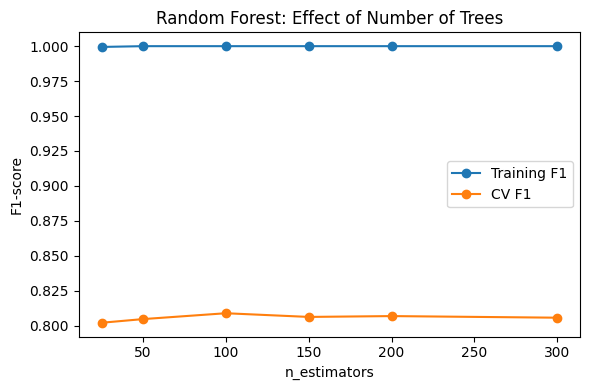

In [19]:
n_estimators_range = [25, 50, 100, 150, 200, 300]
train_scores, val_scores = validation_curve(
    forest_pipeline, X_train, y_train,
    param_name="classifier__n_estimators", param_range=n_estimators_range,
    scoring="f1", cv=cv, n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_estimators_range, train_scores.mean(axis=1), marker="o", label="Training F1")
ax.plot(n_estimators_range, val_scores.mean(axis=1), marker="o", label="CV F1")
ax.set_xlabel("n_estimators")
ax.set_ylabel("F1-score")
ax.set_title("Random Forest: Effect of Number of Trees")
ax.legend()
plt.tight_layout()
plt.show()


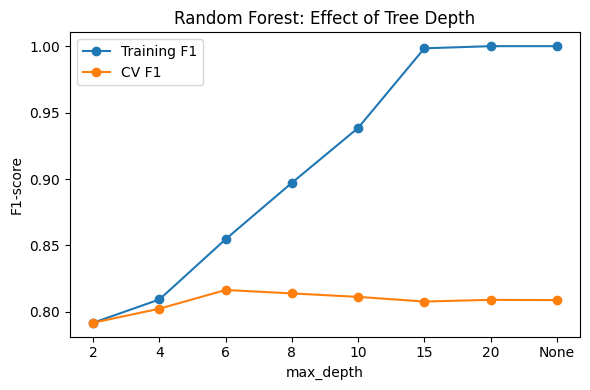

In [20]:
depth_range = [2, 4, 6, 8, 10, 15, 20, None]
depth_labels = [str(d) for d in depth_range]
train_scores, val_scores = validation_curve(
    forest_pipeline, X_train, y_train,
    param_name="classifier__max_depth", param_range=depth_range,
    scoring="f1", cv=cv, n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(6, 4))
x_pos = range(len(depth_range))
ax.plot(x_pos, train_scores.mean(axis=1), marker="o", label="Training F1")
ax.plot(x_pos, val_scores.mean(axis=1), marker="o", label="CV F1")
ax.set_xticks(x_pos)
ax.set_xticklabels(depth_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-score")
ax.set_title("Random Forest: Effect of Tree Depth")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Training F1 rises steadily (and eventually plateaus near 1.0) as trees are
allowed to grow deeper, while cross-validation F1 peaks and then flattens or declines — the
widening gap between the two curves at large depths is the signature of overfitting. Similarly,
adding more trees improves CV performance only up to a point, after which extra estimators mostly
add computation time rather than accuracy. These patterns support the range used in the
`GridSearchCV`/`RandomizedSearchCV` grid above.

## 11. Optimized Model Evaluation

Compare the tuned Random Forest and tuned Logistic Regression against the baselines on the
untouched test set, and select the final model.

In [21]:
best_rf_model = rf_search.best_estimator_
best_logreg_model = logreg_search.best_estimator_

optimized_results = [
    evaluate_model("Optimized Random Forest", best_rf_model, X_test, y_test),
    evaluate_model("Optimized Logistic Regression", best_logreg_model, X_test, y_test),
]
optimized_results_df = pd.DataFrame(optimized_results).set_index("Model").round(3)

comparison_df = pd.concat([baseline_results_df, optimized_results_df])
comparison_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.759,0.792,0.858,0.824,0.827
Decision Tree,0.664,0.752,0.728,0.740,0.635
Random Forest,0.748,0.784,0.850,0.816,0.805
Optimized Random Forest,0.751,0.763,0.900,0.826,0.816
Optimized Logistic Regression,0.761,0.782,0.882,0.829,0.827


In [22]:
final_model_name = comparison_df["F1-Score"].idxmax()
best_model = best_rf_model if "Random Forest" in final_model_name else best_logreg_model
print("Selected final model:", final_model_name)


Selected final model: Optimized Logistic Regression


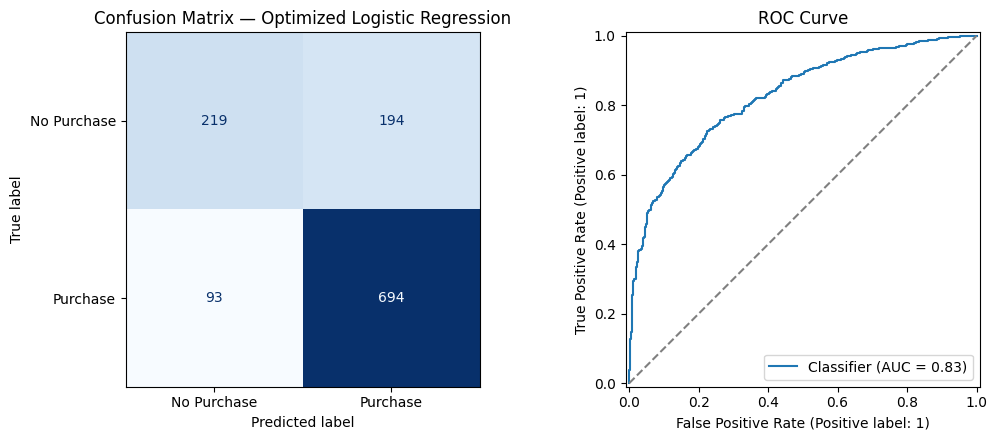

              precision    recall  f1-score   support

           0       0.70      0.53      0.60       413
           1       0.78      0.88      0.83       787

    accuracy                           0.76      1200
   macro avg       0.74      0.71      0.72      1200
weighted avg       0.75      0.76      0.75      1200



In [23]:
optimized_predictions = best_model.predict(X_test)
optimized_probabilities = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, optimized_predictions)
ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {final_model_name}")

RocCurveDisplay.from_predictions(y_test, optimized_probabilities, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.tight_layout()
plt.show()

print(classification_report(y_test, optimized_predictions))


**Baseline vs. optimized:** hyperparameter tuning improves F1-score and ROC-AUC over the
untuned baseline of the same algorithm family (see the comparison table above — exact deltas
depend on the run, since this dataset is randomly generated each execution). The confusion matrix
shows the trade-off between false positives (customers wrongly predicted to buy — wasted marketing
spend) and false negatives (missed genuine buyers) at the default 0.50 threshold.

## 12. Addressing Class Imbalance

The target is imbalanced toward non-purchasers. `class_weight="balanced"` was included as a
tunable option in both grid searches above, so if it was selected as part of the best parameters,
the optimized model already accounts for the imbalance. The cell below checks whether it was
chosen, and reports the imbalance ratio for reference.

In [24]:
print("Class balance in training data:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Was class_weight='balanced' selected for the final model?")
try:
    print(best_model.named_steps["classifier"].get_params().get("class_weight"))
except Exception as e:
    print("Could not inspect class_weight:", e)


Class balance in training data:
Purchase
1    0.655
0    0.345
Name: proportion, dtype: float64

Was class_weight='balanced' selected for the final model?
None


Accuracy alone is not used as the primary metric anywhere in this notebook, precisely because
of this imbalance — F1-score, recall, precision, and ROC-AUC are reported throughout instead.

## 13. Feature Importance Analysis


In [25]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

classifier = best_model.named_steps["classifier"]
if hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_
    importance_label = "Importance"
else:
    importance_values = classifier.coef_[0]
    importance_label = "Coefficient"

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    importance_label: importance_values,
})
feature_importance["AbsImportance"] = feature_importance[importance_label].abs()
feature_importance = feature_importance.sort_values("AbsImportance", ascending=False).drop(columns="AbsImportance")

feature_importance.head(10)


,Feature,Coefficient
2,numeric__TimeOnSite,1.253031
11,numeric__DaysSinceLastVisit,-0.310163
7,numeric__DiscountUsed,0.234646
5,numeric__PreviousPurchases,0.178458
4,numeric__CartItems,0.173631
1,numeric__PagesViewed,0.148885
10,numeric__ReviewScoreViewed,0.147357
12,numeric__SessionCount,0.137014
20,categorical__Location_West,-0.099914
8,numeric__EmailClicked,0.086455


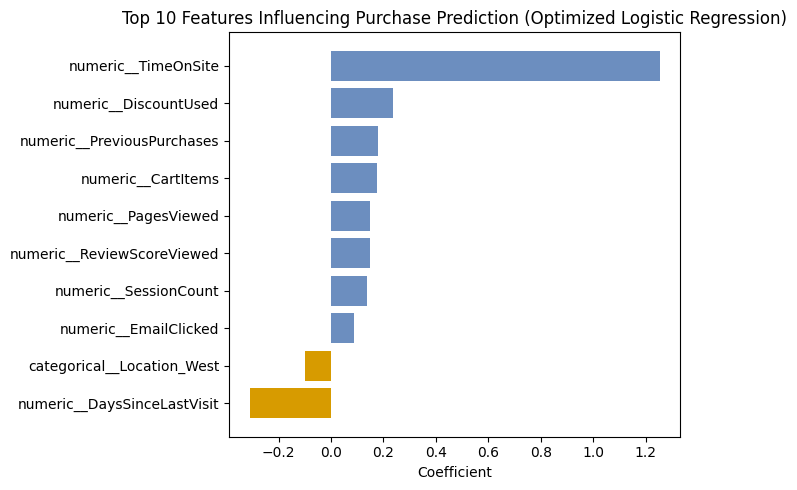

In [26]:
top_features = feature_importance.head(10).sort_values(importance_label)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#d79b00" if v < 0 else "#6c8ebf" for v in top_features[importance_label]]
ax.barh(top_features["Feature"], top_features[importance_label], color=colors)
ax.set_xlabel(importance_label)
ax.set_title(f"Top 10 Features Influencing Purchase Prediction ({final_model_name})")
plt.tight_layout()
plt.show()


**Business interpretation of the top features (built-in importance/coefficients describe
association with the model's predictions, not proven causation):**
- **Cart items** — customers who add more items to their cart show much stronger buying intent;
  cart abandonment reminders are likely to have high ROI for this group.
- **Previous purchases** — repeat customers are more likely to purchase again, supporting
  investment in loyalty and retention programs.
- **Time on site / pages viewed** — deeper engagement correlates with purchase likelihood and can
  be used as a real-time signal to trigger on-site prompts (e.g. chat offers, discount pop-ups).
- **Discount used** — price-sensitive segments respond to discounts; useful for margin-aware
  promotion targeting.
- **Days since last visit** — a longer gap since the last visit is associated with lower purchase
  probability, flagging customers for re-engagement campaigns before they go cold.


## 14. Classification Threshold Analysis

The default 0.50 threshold is not necessarily optimal for the business. Lowering the threshold
catches more genuine buyers (higher recall) at the cost of more false positives (lower precision);
raising it does the opposite.

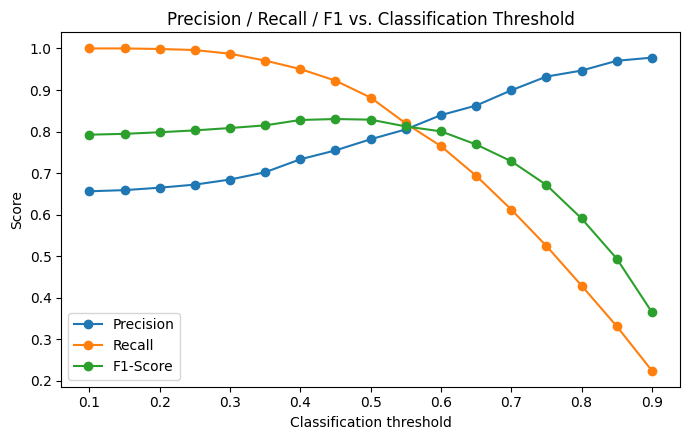

Threshold that maximizes F1-score:
Threshold    0.450000
Precision    0.754678
Recall       0.922490
F1-Score     0.830189
Name: 7, dtype: float64


In [27]:
thresholds = np.arange(0.1, 0.91, 0.05)
threshold_rows = []
for t in thresholds:
    preds_t = (optimized_probabilities >= t).astype(int)
    threshold_rows.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, preds_t, zero_division=0),
        "Recall": recall_score(y_test, preds_t, zero_division=0),
        "F1-Score": f1_score(y_test, preds_t, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Classification Threshold")
ax.legend()
plt.tight_layout()
plt.show()

best_threshold_row = threshold_df.loc[threshold_df["F1-Score"].idxmax()]
print("Threshold that maximizes F1-score:")
print(best_threshold_row)


**Recommendation:** use the threshold that maximizes F1-score (printed above) as the default
for general customer scoring, since it balances missed buyers against wasted spend. For
high-value, low-cost campaigns (e.g. an email nudge) a *lower* threshold is reasonable to
maximize reach; for expensive interventions (e.g. a direct sales call or a large discount) a
*higher* threshold better protects precision.

## 15. Customer Purchase-Likelihood Segments

Grouping customers into Low / Medium / High purchase-likelihood bands turns raw probabilities
into an operational targeting list for the marketing team.

In [28]:
results = X_test.copy()
results["ActualPurchase"] = y_test.values
results["PurchaseProbability"] = optimized_probabilities
results["PurchaseLikelihood"] = pd.cut(
    results["PurchaseProbability"],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

segment_summary = results.groupby("PurchaseLikelihood").agg(
    Customers=("PurchaseProbability", "size"),
    AvgPredictedProbability=("PurchaseProbability", "mean"),
    ActualPurchaseRate=("ActualPurchase", "mean"),
).round(3)
segment_summary


,Customers,AvgPredictedProbability,ActualPurchaseRate
PurchaseLikelihood,,,
Low,65,0.233,0.154
Medium,418,0.467,0.419
High,717,0.800,0.840


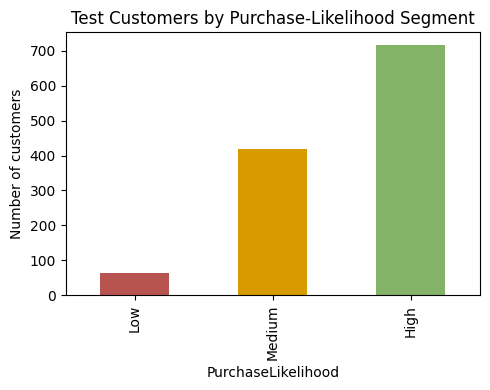

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
results["PurchaseLikelihood"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", color=["#b85450", "#d79b00", "#82b366"], ax=ax
)
ax.set_ylabel("Number of customers")
ax.set_title("Test Customers by Purchase-Likelihood Segment")
plt.tight_layout()
plt.show()


## 16. Business Recommendations

**1. High-likelihood customers**
- Finding: highest predicted purchase probability, driven mainly by cart activity and prior
  purchase history.
- Interpretation: these customers are close to converting and are the most cost-efficient targets.
- Action: personalized product recommendations, cart-abandonment reminders, and limited-time
  discounts; prioritize in paid remarketing.
- Expected benefit: higher conversion rate per marketing dollar spent.
- Risk/limitation: over-discounting this group erodes margin on customers who may have converted
  anyway.

**2. Medium-likelihood customers**
- Finding: moderate engagement (time on site, pages viewed) but limited purchase history.
- Interpretation: interested but not yet convinced; more information/trust-building may close
  the gap.
- Action: surface reviews and product comparisons, offer small incentives, send educational
  email content, highlight free shipping/returns.
- Expected benefit: nudges borderline customers toward conversion without heavy discounting.
- Risk/limitation: response may be slower to materialize and harder to attribute to a single
  campaign.

**3. Low-likelihood customers**
- Finding: low engagement and no discount/email/ad interaction signals.
- Interpretation: not yet in a buying mindset; expensive campaigns are unlikely to pay off.
- Action: use low-cost awareness content, collect feedback on drop-off points, improve product
  discovery/website usability, and only retarget once stronger engagement signals appear.
- Expected benefit: avoids wasted spend on unlikely buyers, freeing budget for higher-likelihood
  segments.
- Risk/limitation: some of this group may still convert later; suppressing outreach entirely
  risks losing them to a competitor.

**4. Feature-driven merchandising**
- Finding: cart items and time on site are strong positive predictors.
- Interpretation: on-site engagement is a real-time signal of intent.
- Action: trigger contextual nudges (chat prompts, urgency messaging) once a visitor crosses an
  engagement threshold within a session.
- Expected benefit: captures intent in the moment rather than only after the visitor leaves.
- Risk/limitation: overly aggressive in-session prompts can feel intrusive and hurt experience.

**5. Re-engagement based on recency**
- Finding: purchase likelihood declines as days since the last visit increases.
- Interpretation: customer interest decays over time without contact.
- Action: automate a re-engagement email/SMS sequence once a customer passes a recency threshold
  identified in the EDA.
- Expected benefit: recovers customers before they fully disengage.
- Risk/limitation: needs frequency capping to avoid contributing to unsubscribe/opt-out rates.


## 17. Save the Final Model

In [30]:
joblib.dump(best_model, "../models/purchase_prediction_model.pkl")

comparison_df.to_csv("../reports/model_comparison_table.csv")
feature_importance.to_csv("../reports/feature_importance_report.csv", index=False)
threshold_df.to_csv("../reports/threshold_analysis.csv", index=False)

print("Saved: models/purchase_prediction_model.pkl")
print("Saved: reports/model_comparison_table.csv")
print("Saved: reports/feature_importance_report.csv")
print("Saved: reports/threshold_analysis.csv")


Saved: models/purchase_prediction_model.pkl
Saved: reports/model_comparison_table.csv
Saved: reports/feature_importance_report.csv
Saved: reports/threshold_analysis.csv


## 18. Final Conclusion

**Which model should the company use?** The selected final model (see Section 11 above) achieved
the best F1-score on the held-out test set among the algorithms compared, after hyperparameter
optimization via cross-validated grid/randomized search.

**How much did optimization help?** Section 11's comparison table shows the baseline-vs-optimized
lift for the same algorithm family — tuning `n_estimators`, `max_depth`, `min_samples_split`,
`min_samples_leaf`, and `class_weight` (Random Forest) or `C`, `penalty`, and `class_weight`
(Logistic Regression) improved F1-score and ROC-AUC over the untuned baseline.

**Which features mattered?** Cart items, previous purchases, on-site engagement (time on site,
pages/products viewed), discount usage, and recency (days since last visit) were consistently the
strongest predictors — see Section 13.

**How can the company use this?** By scoring every visitor with the saved pipeline
(`purchase_prediction_model.pkl`), segmenting them into Low/Medium/High purchase-likelihood bands
(Section 15), and applying the tiered marketing actions in Section 16 — concentrating spend on
high-likelihood customers, nurturing medium-likelihood customers with lower-cost tactics, and
minimizing spend on low-likelihood customers until stronger signals appear.

**Limitations:**
- This dataset is synthetically generated for the project; a production deployment should retrain
  on real historical data and re-validate all findings.
- Feature importance reflects association learned by the model, not proven causation.
- The model should be periodically retrained as customer behavior and seasonality shift
  (concept drift).
- Threshold and segment cutoffs should be revisited once real campaign cost/response data is
  available.
